# Baselines sobre `training_churn_v4` (granularidad mensual)

Replica el análisis del NB 03 (GroupKFold) y NB 04 (split temporal forward) sobre el dataset v4 para responder dos preguntas:

1. **¿v4 mantiene el AUC bajo GroupKFold?** Cota mínima: AUC ≥ 0.75 (para no degradar respecto a v3).
2. **¿v4 reduce el drift temporal?** Cotas a verificar:
   - AUC del split temporal forward **sube** respecto al 0.729 de v3.
   - **Std del AUC por mes** dentro del bloque test es **menor** que el std por campaña en v3 (0.082).

Si ambas se cumplen → v4 reemplaza a v3 como dataset productivo. Si solo cae GroupKFold pero mejora forward → migrar igual por consistencia operativa.

Modelo principal: HGB balanceado (ganador del NB 03).

## 1. Setup y carga

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.cloud import bigquery

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score,
    precision_score, recall_score, precision_recall_curve, roc_curve,
    confusion_matrix,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import lightgbm as lgb
import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
np.random.seed(42)

PROJECT, DATASET = 'glamour-peru-dw', 'glamour_dw'
TABLE = f'`{PROJECT}.{DATASET}.training_churn_v4`'
RANDOM_STATE = 42
N_SPLITS = 5

bq = bigquery.Client(project=PROJECT)
df = bq.query(f'SELECT * FROM {TABLE}').to_dataframe()

print(f'shape           : {df.shape}')
print(f'vendedoras      : {df["id_vendedor"].nunique():,}')
print(f'meses           : {df["mes_obs"].nunique()}')
print(f'churn rate      : {df["churn"].mean():.4f}')
print(f'rango mes_obs   : {df["mes_obs"].min()} → {df["mes_obs"].max()}')
print(f'rango mes_rank  : {df["mes_rank_obs"].min()} → {df["mes_rank_obs"].max()}')
df.head(3)

shape           : (24159, 50)
vendedoras      : 4,241
meses           : 108
churn rate      : 0.3263
rango mes_obs   : 2017-01-01 → 2025-12-01
rango mes_rank  : 3 → 110


,id_vendedor,mes_obs,mes_rank_obs,anio_mes_num,mes_num,fecha_ingreso,edad_vendedor,sexo_vendedor,tipo_vendedor,ccodrelacion,antiguedad_meses,id_coordinadora,edad_coordinadora,ccodubigeo,distrito,provincia,departamento,num_pedidos_obs,monto_total_obs,monto_pagado_obs,num_categorias_obs,num_productos_obs,num_compras_u3,monto_total_u3,monto_pagado_u3,tasa_compra_u3,ticket_promedio_u3,ratio_pago_u3,num_compras_u6,monto_total_u6,monto_pagado_u6,tasa_compra_u6,ticket_promedio_u6,ratio_pago_u6,num_compras_u12,monto_total_u12,monto_pagado_u12,tasa_compra_u12,ticket_promedio_u12,ratio_pago_u12,avg_categorias_u6,avg_productos_u6,unidades_u6,meses_desde_compra_previa,compras_historicas,monto_historico,delta_monto_u3_vs_prev3,delta_compras_u3_vs_prev3,ticket_u3_vs_u12,churn
0,19737065,2021-06-01,56,2021,6,2020-11-23,NaN,F,Asesora,0,8,19735959,NaN,PE210009,castilla,piura,piura,1,175.18,141.39,1,3,1,175.18,141.39,0.333333,175.18,0.807113,4,1491.98,1103.95,0.666667,372.9950,0.739923,6,2926.75,2099.59,0.750000,487.791667,0.717379,1.000000,4.166667,27.0,3,6,2926.75,-0.765171,-0.5,0.359129,0
1,19735387,2021-06-01,56,2021,6,2019-08-09,NaN,F,Asesora,0,23,19721983,47.0,PE050009,ayacucho,huamanga,ayacucho,1,273.38,201.37,1,4,1,273.38,201.37,0.333333,273.38,0.736594,4,1896.11,1396.59,0.666667,474.0275,0.736555,4,1896.11,1396.59,0.333333,474.027500,0.736555,1.333333,5.000000,35.0,3,7,2868.98,-0.711641,-0.5,0.576718,0
2,19737258,2021-06-01,56,2021,6,2021-01-26,NaN,F,Asesora,0,6,19721983,47.0,PE160013,azangaro,Yauyos,Lima,1,330.17,259.12,1,6,1,330.17,259.12,0.333333,330.17,0.784808,4,1597.99,1176.59,0.666667,399.4975,0.736294,4,1597.99,1176.59,0.666667,399.497500,0.736294,0.833333,4.000000,27.0,3,4,1597.99,-0.586768,-0.5,0.826463,0


## 2. Features y pipeline

Mismas exclusiones que NB 03, adaptando los nombres de v4:
- IDs/claves: `id_vendedor`, `mes_obs`, `mes_rank_obs`.
- Fechas crudas: `fecha_ingreso` (no hay `fecha_inicio_campana` en v4).
- Categóricas de alta cardinalidad: `id_coordinadora`, `ccodubigeo`, `distrito`.
- Target: `churn`.

In [2]:
EXCLUDE = {
    'id_vendedor', 'mes_obs', 'mes_rank_obs',
    'fecha_ingreso',
    'id_coordinadora', 'ccodubigeo', 'distrito',
    'churn',
}
CATEGORICAL = ['sexo_vendedor', 'tipo_vendedor', 'departamento', 'provincia']
feature_cols = [c for c in df.columns if c not in EXCLUDE]
numeric_cols = [c for c in feature_cols if c not in CATEGORICAL]

for c in CATEGORICAL:
    df[c] = df[c].astype('string').fillna('NA')

X = df[feature_cols].copy()
y = df['churn'].astype(int).values
groups = df['id_vendedor'].values

print(f'#features   : {len(feature_cols)}')
print(f'#numéricas  : {len(numeric_cols)}')
print(f'#categóricas: {len(CATEGORICAL)}  (cardinalidades: {[X[c].nunique() for c in CATEGORICAL]})')
print(f'positivos   : {y.sum():,} ({y.mean()*100:.2f}%)')

def build_preprocessor(scale=False):
    num_steps = [('impute', SimpleImputer(strategy='median'))]
    if scale: num_steps.append(('scale', StandardScaler()))
    return ColumnTransformer([
        ('num', Pipeline(num_steps), numeric_cols),
        ('cat', Pipeline([
            ('impute', SimpleImputer(strategy='constant', fill_value='NA')),
            ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), CATEGORICAL),
    ])

#features   : 42
#numéricas  : 38
#categóricas: 4  (cardinalidades: [4, 2, 33, 154])
positivos   : 7,883 (32.63%)


## 3. Función de evaluación con GroupKFold (idéntica al NB 03)

In [3]:
cv = GroupKFold(n_splits=N_SPLITS)

def evaluate(model_factory, X, y, groups, name, predict_proba=True):
    oof = np.zeros(len(y), dtype=float)
    fold_aucs, fold_aps = [], []
    for tr, te in cv.split(X, y, groups):
        Xtr, Xte = X.iloc[tr], X.iloc[te]
        ytr, yte = y[tr], y[te]
        if predict_proba:
            m = model_factory(); m.fit(Xtr, ytr)
            proba = m.predict_proba(Xte)[:, 1]
        else:
            proba = model_factory()(Xte)
        oof[te] = proba
        fold_aucs.append(roc_auc_score(yte, proba))
        fold_aps.append(average_precision_score(yte, proba))

    pred05 = (oof >= 0.5).astype(int)
    p, r, t = precision_recall_curve(y, oof)
    f1 = 2 * p * r / np.clip(p + r, 1e-12, None)
    bi = int(np.argmax(f1[:-1]))
    bt = float(t[bi])
    pb = (oof >= bt).astype(int)

    return {
        'name': name, 'oof': oof,
        'auc_mean': np.mean(fold_aucs), 'auc_std': np.std(fold_aucs),
        'ap_mean': np.mean(fold_aps), 'ap_std': np.std(fold_aps),
        'auc_oof': roc_auc_score(y, oof), 'ap_oof': average_precision_score(y, oof),
        'f1_05': f1_score(y, pred05),
        'precision_05': precision_score(y, pred05, zero_division=0),
        'recall_05': recall_score(y, pred05),
        'best_thr': bt, 'f1_best': f1_score(y, pb),
        'precision_best': precision_score(y, pb, zero_division=0),
        'recall_best': recall_score(y, pb),
    }

def summarize(results):
    return pd.DataFrame([{
        'modelo': r['name'],
        'AUC (mean ± std)': f"{r['auc_mean']:.4f} ± {r['auc_std']:.4f}",
        'PR-AUC (mean ± std)': f"{r['ap_mean']:.4f} ± {r['ap_std']:.4f}",
        'F1@0.5': f"{r['f1_05']:.3f}",
        'Recall@0.5': f"{r['recall_05']:.3f}",
        'Precision@0.5': f"{r['precision_05']:.3f}",
        'best thr': f"{r['best_thr']:.3f}",
        'F1@best': f"{r['f1_best']:.3f}",
        'Recall@best': f"{r['recall_best']:.3f}",
        'Precision@best': f"{r['precision_best']:.3f}",
    } for r in results])

# Sanity: GroupKFold con 0 vendedoras compartidas
for tr, te in cv.split(X, y, groups):
    assert not (set(groups[tr]) & set(groups[te]))
print(f'OK — GroupKFold {N_SPLITS} folds, sin solapamiento de vendedoras.')

OK — GroupKFold 5 folds, sin solapamiento de vendedoras.


## 4. Baselines bajo GroupKFold

Mismos 6 modelos que NB 03. La heurística ahora usa `meses_desde_compra_previa` (mismo concepto, escala mensual).

In [4]:
def make_dummy():
    return Pipeline([('prep', build_preprocessor(False)),
                     ('clf', DummyClassifier(strategy='stratified', random_state=RANDOM_STATE))])

def make_heuristic():
    def scorer(Xte):
        gap = Xte['meses_desde_compra_previa'].fillna(0).astype(float).values
        return 1.0 - np.exp(-gap / 4.0)   # escala alineada al horizonte de churn
    return scorer

def make_logreg():
    return Pipeline([('prep', build_preprocessor(True)),
                     ('clf', LogisticRegression(max_iter=2000, class_weight='balanced',
                                                random_state=RANDOM_STATE, n_jobs=-1))])

def make_hgb():
    return Pipeline([('prep', build_preprocessor(False)),
                     ('clf', HistGradientBoostingClassifier(class_weight='balanced',
                                                            max_iter=400, learning_rate=0.05,
                                                            random_state=RANDOM_STATE,
                                                            early_stopping=False))])

def make_lgbm():
    return Pipeline([('prep', build_preprocessor(False)),
                     ('clf', lgb.LGBMClassifier(n_estimators=600, learning_rate=0.05,
                                                num_leaves=63, min_child_samples=40,
                                                subsample=0.9, colsample_bytree=0.9,
                                                is_unbalance=True, random_state=RANDOM_STATE,
                                                n_jobs=-1, verbose=-1))])

p_pos = float(y.mean())
def make_xgb():
    return Pipeline([('prep', build_preprocessor(False)),
                     ('clf', xgb.XGBClassifier(n_estimators=600, learning_rate=0.05, max_depth=6,
                                               min_child_weight=5, subsample=0.9, colsample_bytree=0.9,
                                               scale_pos_weight=(1 - p_pos) / p_pos,
                                               objective='binary:logistic', eval_metric='auc',
                                               tree_method='hist', random_state=RANDOM_STATE,
                                               n_jobs=-1))])

results = []
for name, fac, pp in [
    ('Dummy (stratified)',          make_dummy,     True),
    ('Heurística (gap previo)',     make_heuristic, False),
    ('LogReg (balanced)',           make_logreg,    True),
    ('HGB (balanced)',              make_hgb,       True),
    ('LightGBM (unbalanced)',       make_lgbm,      True),
    ('XGBoost (scale_pos_weight)',  make_xgb,       True),
]:
    print(f'→ entrenando {name} ...', flush=True)
    r = evaluate(fac, X, y, groups, name=name, predict_proba=pp)
    results.append(r)
    print(f'   AUC OOF {r["auc_oof"]:.4f}  PR-AUC {r["ap_oof"]:.4f}')

summarize(results)

→ entrenando Dummy (stratified) ...
   AUC OOF 0.5014  PR-AUC 0.3269
→ entrenando Heurística (gap previo) ...
   AUC OOF 0.6551  PR-AUC 0.4663
→ entrenando LogReg (balanced) ...
   AUC OOF 0.7403  PR-AUC 0.5487
→ entrenando HGB (balanced) ...
   AUC OOF 0.7413  PR-AUC 0.5531
→ entrenando LightGBM (unbalanced) ...
   AUC OOF 0.7288  PR-AUC 0.5325
→ entrenando XGBoost (scale_pos_weight) ...
   AUC OOF 0.7373  PR-AUC 0.5445


,modelo,AUC (mean ± std),PR-AUC (mean ± std),F1@0.5,Recall@0.5,Precision@0.5,best thr,F1@best,Recall@best,Precision@best
0,Dummy (stratified),0.5014 ± 0.0040,0.3270 ± 0.0086,0.326,0.323,0.328,0.000,0.492,1.000,0.326
1,Heurística (gap previo),0.6550 ± 0.0056,0.4669 ± 0.0137,0.495,0.500,0.491,0.393,0.523,0.669,0.429
2,LogReg (balanced),0.7400 ± 0.0088,0.5497 ± 0.0058,0.581,0.731,0.482,0.449,0.586,0.800,0.462
3,HGB (balanced),0.7411 ± 0.0073,0.5543 ± 0.0117,0.579,0.694,0.497,0.407,0.586,0.808,0.459
4,LightGBM (unbalanced),0.7287 ± 0.0081,0.5335 ± 0.0110,0.548,0.604,0.502,0.287,0.581,0.844,0.442
5,XGBoost (scale_pos_weight),0.7372 ± 0.0069,0.5456 ± 0.0111,0.574,0.681,0.497,0.423,0.586,0.781,0.469


## 5. Curvas ROC y PR (todos los modelos)

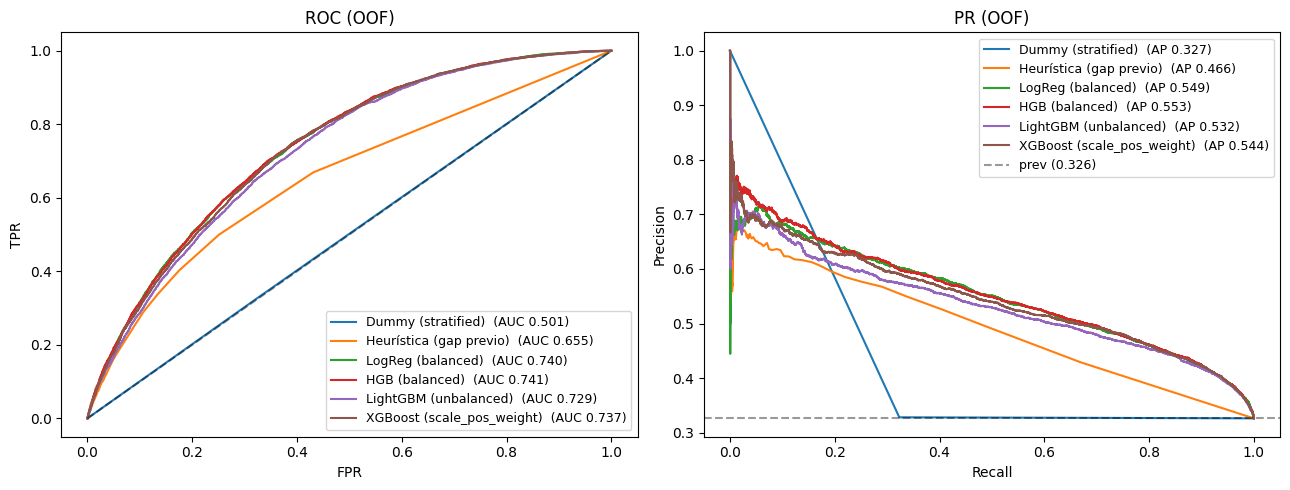

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
prev = y.mean()
for r in results:
    fpr, tpr, _ = roc_curve(y, r['oof'])
    axes[0].plot(fpr, tpr, label=f"{r['name']}  (AUC {r['auc_oof']:.3f})")
    p, rc, _ = precision_recall_curve(y, r['oof'])
    axes[1].plot(rc, p, label=f"{r['name']}  (AP {r['ap_oof']:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC (OOF)'); axes[0].legend(fontsize=9)
axes[1].axhline(prev, ls='--', color='k', alpha=0.4, label=f'prev ({prev:.3f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('PR (OOF)'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.show()

## 6. Comparación lado a lado: v3 vs v4 (GroupKFold)

Los números de v3 vienen del NB 03 (mismo hardware, mismas seeds).

In [6]:
v3_bench = {
    'Dummy (stratified)':         {'auc': 0.5014, 'ap': 0.2795},
    'Heurística (gap previo)':    {'auc': 0.6771, 'ap': 0.4404},
    'LogReg (balanced)':          {'auc': 0.7456, 'ap': 0.5023},
    'HGB (balanced)':             {'auc': 0.7541, 'ap': 0.5229},
    'LightGBM (unbalanced)':      {'auc': 0.7446, 'ap': 0.5054},
    'XGBoost (scale_pos_weight)': {'auc': 0.7505, 'ap': 0.5176},
}
rows = []
for r in results:
    v3 = v3_bench.get(r['name'], {})
    auc_v3 = v3.get('auc', np.nan); ap_v3 = v3.get('ap', np.nan)
    rows.append({
        'modelo': r['name'],
        'AUC v3': f'{auc_v3:.4f}' if auc_v3 == auc_v3 else '—',
        'AUC v4': f"{r['auc_oof']:.4f}",
        'Δ AUC':  f"{(r['auc_oof'] - auc_v3):+.4f}" if auc_v3 == auc_v3 else '—',
        'PR-AUC v3': f'{ap_v3:.4f}' if ap_v3 == ap_v3 else '—',
        'PR-AUC v4': f"{r['ap_oof']:.4f}",
        'Δ PR-AUC': f"{(r['ap_oof'] - ap_v3):+.4f}" if ap_v3 == ap_v3 else '—',
    })
pd.DataFrame(rows)

,modelo,AUC v3,AUC v4,Δ AUC,PR-AUC v3,PR-AUC v4,Δ PR-AUC
0,Dummy (stratified),0.5014,0.5014,-0.0000,0.2795,0.3269,+0.0474
1,Heurística (gap previo),0.6771,0.6551,-0.0220,0.4404,0.4663,+0.0259
2,LogReg (balanced),0.7456,0.7403,-0.0053,0.5023,0.5487,+0.0464
3,HGB (balanced),0.7541,0.7413,-0.0128,0.5229,0.5531,+0.0302
4,LightGBM (unbalanced),0.7446,0.7288,-0.0158,0.5054,0.5325,+0.0271
5,XGBoost (scale_pos_weight),0.7505,0.7373,-0.0132,0.5176,0.5445,+0.0269


## 7. Split temporal forward — replicar NB 04 sobre v4

- **Test**: bloque de los **últimos 6 meses** del dataset.
- **Train**: `mes_rank_obs ≤ (test_min_rank − 5)`.
- **GAP = 5 meses** = `HORIZON_CHURN (4) + 1`. Asegura que el target del último train (que mira 4 meses adelante) termine antes del primer mes del test.

Modelo: HGB balanceado.

Comparación clave contra v3:
- AUC bloque test: v3 = 0.729 → v4 ¿sube?
- Std AUC por mes test: v3 = 0.082 → v4 ¿baja?
- Diferencia churn rate train vs test: v3 = +8.2pp → v4 ¿menor?

In [7]:
TEST_WINDOW = 6
GAP = 5

last_rank = int(df['mes_rank_obs'].max())
test_min = last_rank - TEST_WINDOW + 1
train_max = test_min - GAP

train_mask_t = df['mes_rank_obs'] <= train_max
test_mask_t  = df['mes_rank_obs'].between(test_min, last_rank)

df_train_t = df.loc[train_mask_t]
df_test_t  = df.loc[test_mask_t]

X_train_t, y_train_t = df_train_t[feature_cols], df_train_t['churn'].astype(int).values
X_test_t,  y_test_t  = df_test_t[feature_cols],  df_test_t['churn'].astype(int).values

model_t = make_hgb()
model_t.fit(X_train_t, y_train_t)
proba_t = model_t.predict_proba(X_test_t)[:, 1]

print(f'Train: mes_rank_obs ≤ {train_max}  →  {len(df_train_t):,} filas · '
      f'{df_train_t["id_vendedor"].nunique():,} vendedoras · '
      f'churn rate {df_train_t["churn"].mean():.4f}')
print(f'Test : mes_rank_obs ∈ [{test_min}, {last_rank}]  →  {len(df_test_t):,} filas · '
      f'{df_test_t["id_vendedor"].nunique():,} vendedoras · '
      f'churn rate {df_test_t["churn"].mean():.4f}')
overlap = len(set(df_train_t['id_vendedor']) & set(df_test_t['id_vendedor']))
print(f'Vendedoras presentes en train Y test: {overlap:,} '
      f'({overlap / df_test_t["id_vendedor"].nunique() * 100:.1f}% del test)')

auc_t = roc_auc_score(y_test_t, proba_t)
ap_t  = average_precision_score(y_test_t, proba_t)
pred_t = (proba_t >= 0.5).astype(int)

print()
print(f'ROC-AUC      : {auc_t:.4f}  (NB 04 v3 = 0.7294)')
print(f'PR-AUC       : {ap_t:.4f}  (prevalencia test {y_test_t.mean():.4f})')
print(f'F1@0.5       : {f1_score(y_test_t, pred_t):.3f}')
print(f'Recall@0.5   : {recall_score(y_test_t, pred_t):.3f}')
print(f'Precision@0.5: {precision_score(y_test_t, pred_t, zero_division=0):.3f}')
print()
cm = confusion_matrix(y_test_t, pred_t)
print('Matriz de confusión @ thr=0.5')
print(pd.DataFrame(cm, index=['real: no-churn', 'real: churn'],
                   columns=['pred: no-churn', 'pred: churn']))

Train: mes_rank_obs ≤ 100  →  22,243 filas · 4,079 vendedoras · churn rate 0.3258
Test : mes_rank_obs ∈ [105, 110]  →  1,164 filas · 587 vendedoras · churn rate 0.3222
Vendedoras presentes en train Y test: 465 (79.2% del test)

ROC-AUC      : 0.7286  (NB 04 v3 = 0.7294)
PR-AUC       : 0.5283  (prevalencia test 0.3222)
F1@0.5       : 0.556
Recall@0.5   : 0.685
Precision@0.5: 0.467

Matriz de confusión @ thr=0.5
                pred: no-churn  pred: churn
real: no-churn             496          293
real: churn                118          257


## 8. Estabilidad por mes dentro del test

El número clave: si la **std de AUC por mes** es menor que 0.082 (v3), v4 ganó la apuesta de consistencia temporal.

In [8]:
eval_t = df_test_t[['mes_rank_obs', 'mes_obs', 'churn']].copy()
eval_t['proba'] = proba_t

per_mes = []
for r, g in eval_t.groupby('mes_rank_obs'):
    yt = g['churn'].astype(int).values
    pp = g['proba'].values
    n_pos = int(yt.sum())
    auc_v = roc_auc_score(yt, pp) if 0 < n_pos < len(yt) else np.nan
    ap_v  = average_precision_score(yt, pp) if n_pos else np.nan
    per_mes.append({
        'rank': int(r),
        'mes': str(g['mes_obs'].iloc[0])[:10],
        'n': len(yt), 'n_churn': n_pos,
        'churn_rate': float(yt.mean()),
        'AUC': auc_v, 'AP': ap_v,
    })
per_mes = pd.DataFrame(per_mes).sort_values('rank').reset_index(drop=True)
print(per_mes.to_string(index=False))
print()
print(f"AUC por mes — media {per_mes['AUC'].mean():.3f}, "
      f"std {per_mes['AUC'].std():.3f}, "
      f"min {per_mes['AUC'].min():.3f}, max {per_mes['AUC'].max():.3f}")
print(f"AUC bloque agregado: {auc_t:.3f}")
print()
print(f"Comparación con NB 04 (v3):  std AUC v3 = 0.082, v4 = {per_mes['AUC'].std():.3f}  "
      f"→ {'MEJOR (más estable)' if per_mes['AUC'].std() < 0.082 else 'peor o igual'}")

 rank        mes   n  n_churn  churn_rate      AUC       AP
  105 2025-07-01 155       53    0.341935 0.773400 0.638983
  106 2025-08-01 177       54    0.305085 0.727191 0.473242
  107 2025-09-01 182       56    0.307692 0.687075 0.468442
  108 2025-10-01 175       48    0.274286 0.737369 0.487090
  109 2025-11-01 224       71    0.316964 0.743073 0.546040
  110 2025-12-01 251       93    0.370518 0.709950 0.570205

AUC por mes — media 0.730, std 0.030, min 0.687, max 0.773
AUC bloque agregado: 0.729

Comparación con NB 04 (v3):  std AUC v3 = 0.082, v4 = 0.030  → MEJOR (más estable)


## 9. Veredicto

**Criterios de aceptación de v4 sobre v3** (a llenar después de correr):

| Criterio | Cota | Resultado | Pasa |
|---|---|---|---|
| AUC GroupKFold (mejor modelo) | ≥ 0.75 | _completar_ | ☐ |
| AUC split forward | > 0.729 | _completar_ | ☐ |
| Std AUC por mes (test) | < 0.082 | _completar_ | ☐ |
| Δ churn rate train vs test | < 8.2pp | _completar_ | ☐ |

**Decisión:**

- **3+ criterios pasan** → migrar a v4 como dataset productivo. Actualizar `STATUS.md`.
- **Solo GroupKFold pasa pero forward sigue mal** → el drift no era de granularidad, hay otro factor (revisar features de coordinadora/ubigeo, recalibración periódica).
- **GroupKFold cae > 0.02** → revisar si la limpieza de campañas removió señal útil; o si `HORIZON_CHURN = 4` es muy corto.